## Scenario Intervention Figures
These final plots focus on **behavioral response under the storm prompt** under the `new10` taxonomy.

- **Figure A**: average visited locations by weekday, with Tuesday and Saturday marked as storm days.
- **Figure B**: week-long grouped stacked activity mix, with weekday groups and storm-day shading.


In [1]:
from pathlib import Path
import sys

analysis_dir = Path.cwd() / "analysis"
if analysis_dir.exists() and str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from constants import NEW_LOC_TYPES
from evals import make_weekday_location_figure, make_weekly_activity_mix_figure
from utils import load_simulation_run_dict
from agent_story import show_agent_story_compare as _base_show_agent_story_compare

In [2]:
SIM_RUNS = {
    "OSS_20B": "simulation_outputs/SF_storm_1k_oss_20b",
    "OSS_120B": "simulation_outputs/SF_storm_1k_oss_120b",
    "OSS-20B-FT-SF": "simulation_outputs/SF_storm_1k_oss_20b_lora-sf-5epoch",
    "OSS-20B-FT-US": "simulation_outputs/SF_storm_1k_oss_20b_lora-5epoch",
}

SIM_RUN_INPUT_FOLDERS = {
    "OSS_20B": "Inputs/SF_agents_1K",
    "OSS_120B": "Inputs/SF_agents_1K",
    "OSS-20B-FT-SF": "Inputs/SF_agents_1K",
    "OSS-20B-FT-US": "Inputs/SF_agents_1K",
}

SEED = 42
TARGET_TAXONOMY = "new10"
DAY_ORDER = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]
DAY_SHORT_LABELS = {
    "Monday": "Mon",
    "Tuesday": "Tue",
    "Wednesday": "Wed",
    "Thursday": "Thu",
    "Friday": "Fri",
    "Saturday": "Sat",
    "Sunday": "Sun",
}
STORM_DAY_NAMES = {"Tuesday", "Saturday"}

MODEL_ORDER = [
    "OSS_120B",
    "OSS_20B",
    "OSS-20B-FT-SF",
    "OSS-20B-FT-US",
]
MODEL_DISPLAY = {
    "OSS_120B": "OSS-120B",
    "OSS_20B": "OSS-20B",
    "OSS-20B-FT-SF": "OSS-20B-FT-SF",
    "OSS-20B-FT-US": "OSS-20B-FT-US",
}
MODEL_SHORT = {
    "OSS_120B": "120B",
    "OSS_20B": "20B",
    "OSS-20B-FT-SF": "FT-SF",
    "OSS-20B-FT-US": "FT-US",
}
MODEL_COLORS = {
    "OSS_120B": "#4e79a7",
    "OSS_20B": "#f28e2b",
    "OSS-20B-FT-SF": "#e15759",
    "OSS-20B-FT-US": "#76b7b2",
}

ACTIVITY_CODES = [2, 4, 3, 5, 6, 10, 7, 8, 9]
ACTIVITY_LABELS = {code: NEW_LOC_TYPES[code] for code in ACTIVITY_CODES}
ACTIVITY_COLORS = {
    2: "#4e79a7",
    4: "#59a14f",
    3: "#f28e2b",
    5: "#e15759",
    6: "#edc948",
    10: "#b07aa1",
    7: "#ff9da7",
    8: "#9c755f",
    9: "#bab0ab",
}

DEFAULT_FIGSIZE = (15, 8)
DEFAULT_FONT_SIZE = 24
DEFAULT_FONT_SIZE_S = 24
DEFAULT_FONT_SIZE_WS = 16

LINE_LEGEND_NCOL = 4
LINE_LEGEND_LOC = "upper center"
LINE_LEGEND_BBOX = (0.5, 1.18)

WEEKLY_LEGEND_NCOL = 1
WEEKLY_LEGEND_LOC = "center left"
WEEKLY_LEGEND_BBOX = (0.99, 0.5)

def show_agent_story_compare(
    agent_id,
    models=None,
    days=None,
    show_profile=True,
    show_day_plan_reasoning=True,
    show_day_plan=True,
    show_step_reasoning=True,
    show_step_activity=True,
    show_step_rationale=True,
    show_step_stay_minutes=True,
    show_reflection_reasoning=True,
    show_reflection=True,
):
    """Render compact per-model, per-day reasoning traces for one agent.

    Parameters
    ----------
    agent_id : int
        Agent id shared across the selected model runs.
    models : list[str] | None
        Keys from SIM_RUNS / MODEL_DISPLAY. Defaults to MODEL_ORDER.
    days : list[int] | None
        1-based simulation days, e.g. [2, 6] for Tuesday and Saturday when Monday is day 1.
    """
    chosen_models = list(MODEL_ORDER if models is None else models)
    chosen_days = list([2, 6] if days is None else days)
    return _base_show_agent_story_compare(
        agent_id=int(agent_id),
        sim_runs=SIM_RUNS,
        run_input_folders=SIM_RUN_INPUT_FOLDERS,
        models=chosen_models,
        days=chosen_days,
        model_display=MODEL_DISPLAY,
        storm_day_names=STORM_DAY_NAMES,
        show_profile=show_profile,
        show_day_plan_reasoning=show_day_plan_reasoning,
        show_day_plan=show_day_plan,
        show_step_reasoning=show_step_reasoning,
        show_step_activity=show_step_activity,
        show_step_rationale=show_step_rationale,
        show_step_stay_minutes=show_step_stay_minutes,
        show_reflection_reasoning=show_reflection_reasoning,
        show_reflection=show_reflection,
    )




In [3]:
scenario_frames = load_simulation_run_dict(
    SIM_RUNS,
    day_selector="all",
    seed=SEED,
    run_input_folders=SIM_RUN_INPUT_FOLDERS,
    target_taxonomy=TARGET_TAXONOMY,
)

for name in MODEL_ORDER:
    df = scenario_frames[name]
    print(name, len(df), "rows", df["agent_id"].nunique(), "agents")


[cohort-join] OSS_20B: joined from Inputs/SF_agents_1K
Normalizing simulation dataframe with columns: ['agent_id', 'agent_type', 'combined_time', 'date', 'graph', 'loc_type', 'loc_type2', 'loc_type_new', 'location', 'person_class', 'travel_time', 'travel_times']
[cohort-join] OSS_120B: joined from Inputs/SF_agents_1K
Normalizing simulation dataframe with columns: ['agent_id', 'agent_type', 'combined_time', 'date', 'graph', 'loc_type', 'loc_type2', 'loc_type_new', 'location', 'person_class', 'travel_time', 'travel_times']
[cohort-join] OSS-20B-FT-SF: joined from Inputs/SF_agents_1K
Normalizing simulation dataframe with columns: ['agent_id', 'agent_type', 'combined_time', 'date', 'graph', 'loc_type', 'loc_type2', 'loc_type_new', 'location', 'person_class', 'travel_time', 'travel_times']
[cohort-join] OSS-20B-FT-US: joined from Inputs/SF_agents_1K
Normalizing simulation dataframe with columns: ['agent_id', 'agent_type', 'combined_time', 'date', 'graph', 'loc_type', 'loc_type2', 'loc_type_

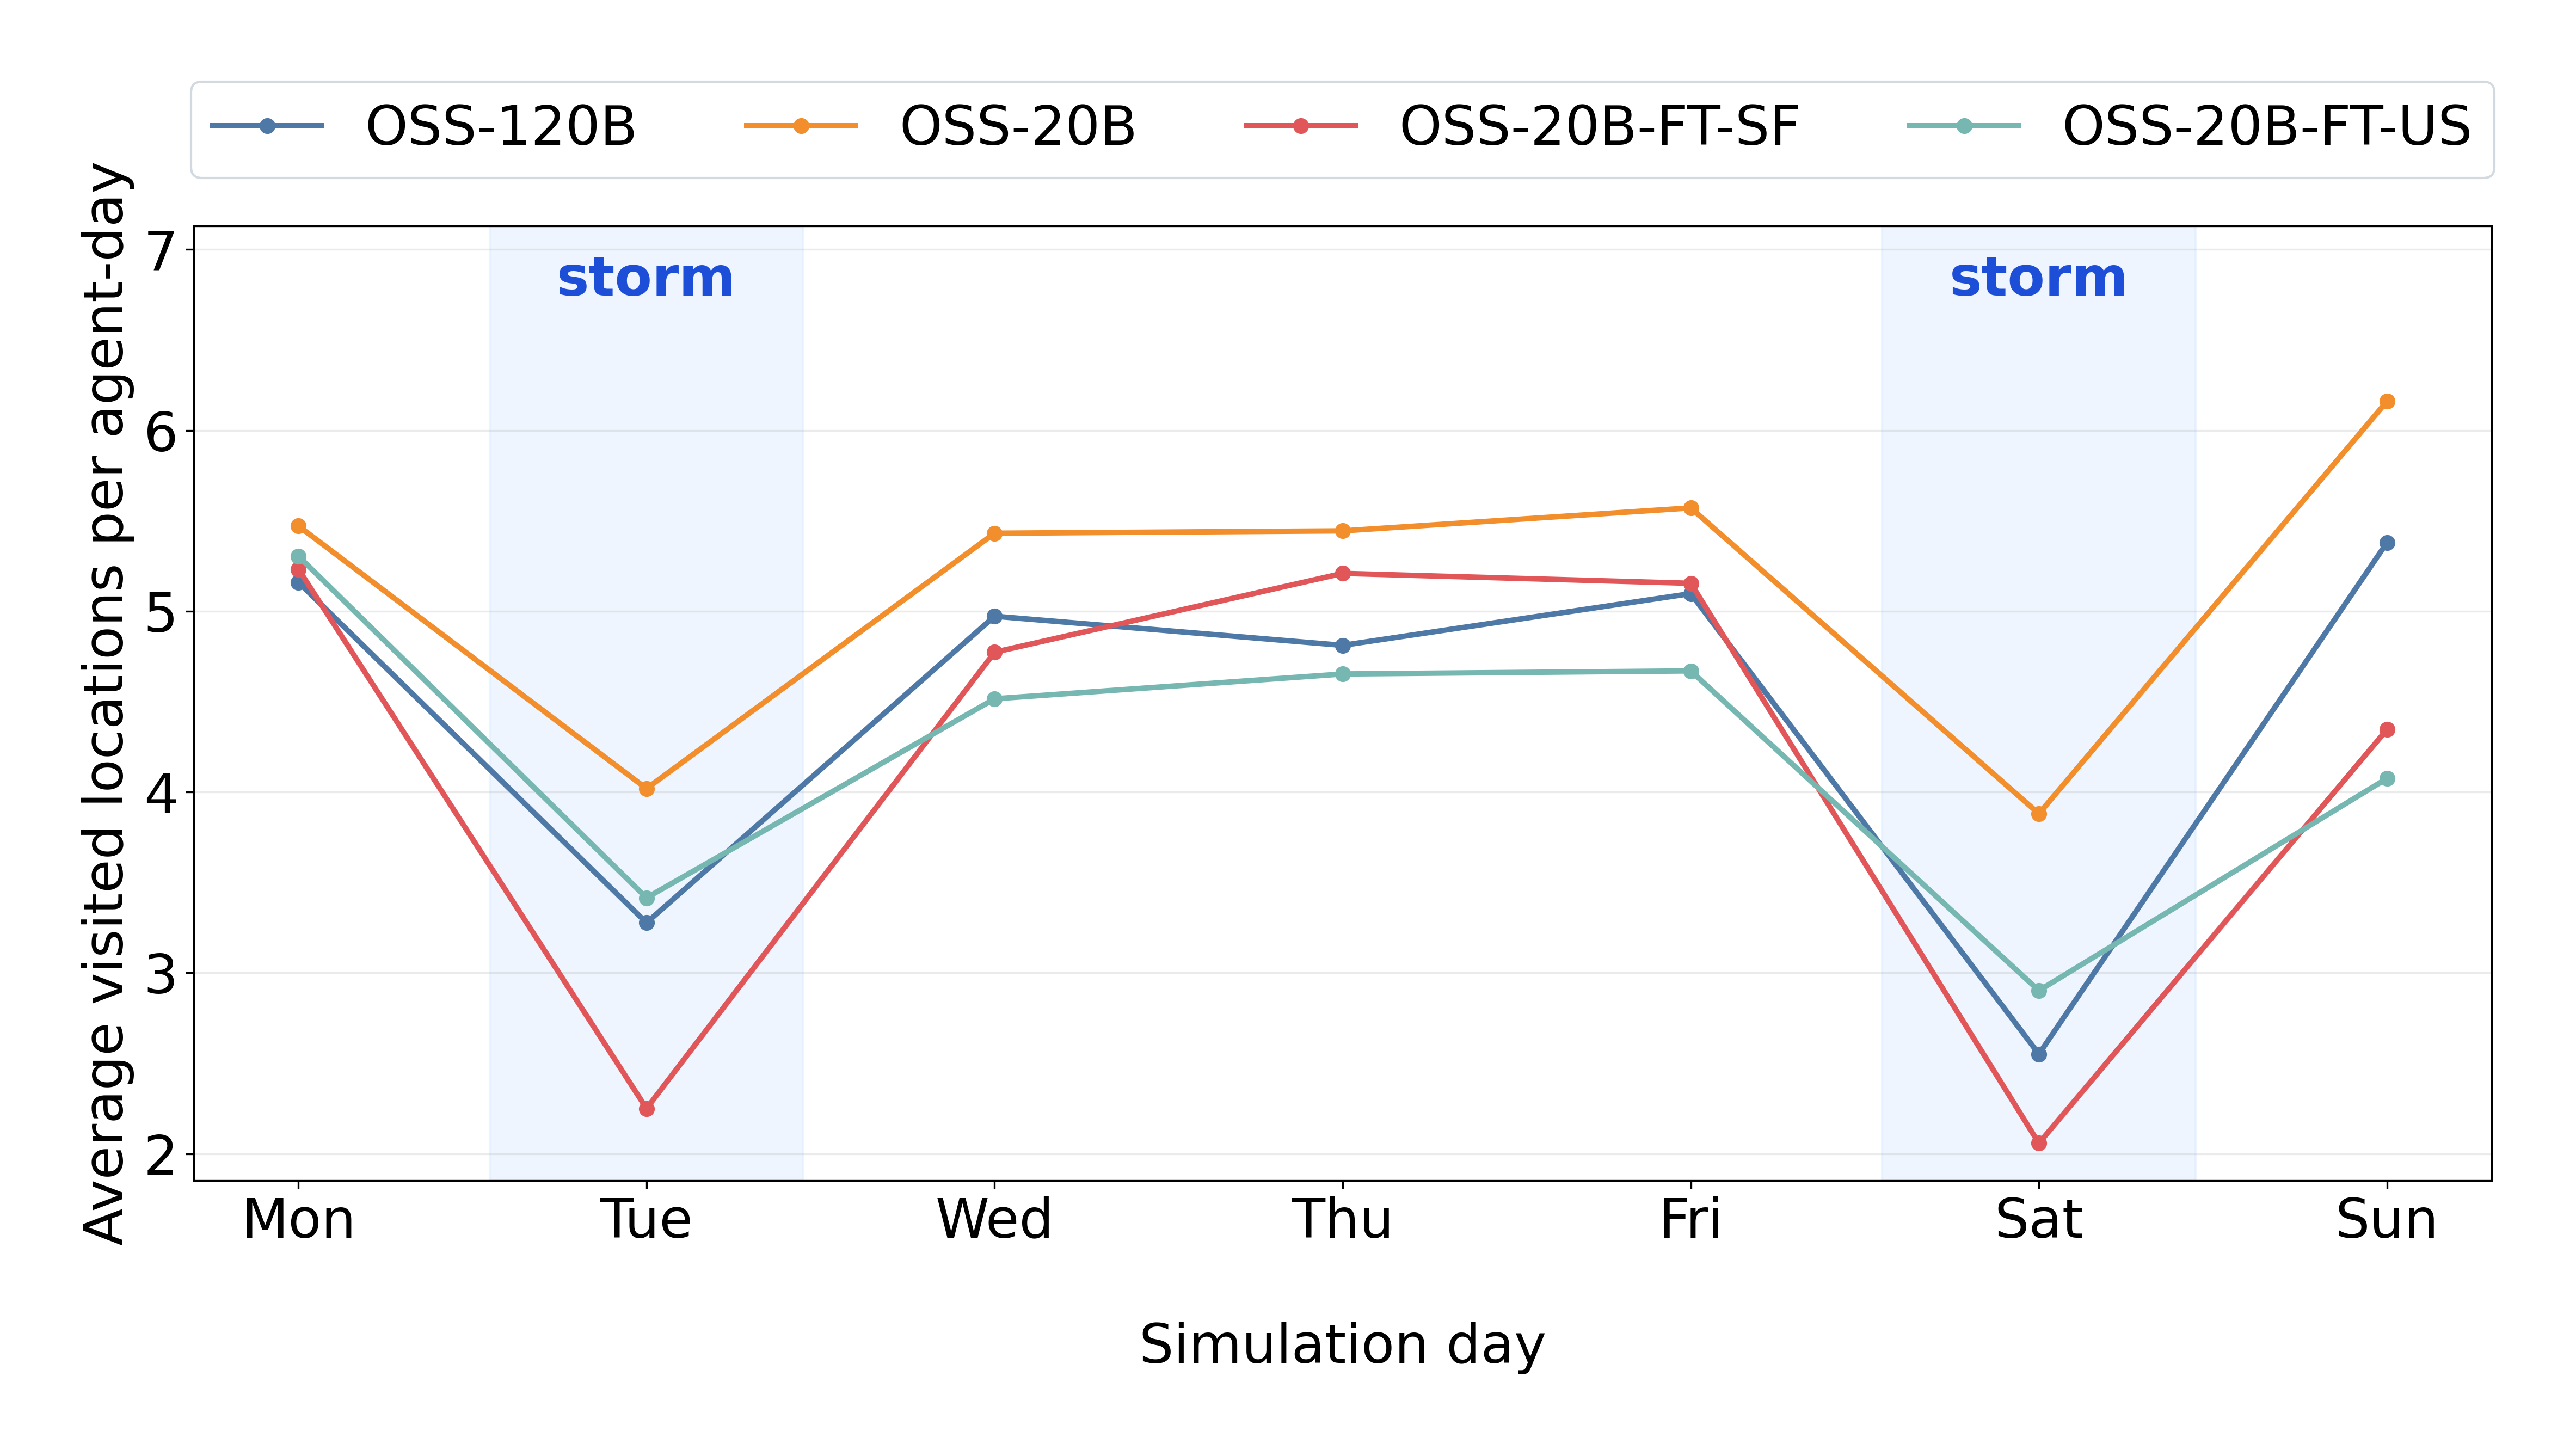

In [4]:
fig_daily, ax_daily, scenario_daily_summary = make_weekday_location_figure(
    scenario_frames,
    model_order=MODEL_ORDER,
    day_order=DAY_ORDER,
    day_short_labels=DAY_SHORT_LABELS,
    storm_day_names=STORM_DAY_NAMES,
    model_colors=MODEL_COLORS,
    model_display=MODEL_DISPLAY,
    legend_ncol=LINE_LEGEND_NCOL,
    legend_loc=LINE_LEGEND_LOC,
    legend_bbox_to_anchor=LINE_LEGEND_BBOX,
    font_size=DEFAULT_FONT_SIZE,
    font_size_s=DEFAULT_FONT_SIZE_S,
    figsize=DEFAULT_FIGSIZE,
)

# fig_daily.savefig(
#     "/Users/prb977/Project/MMv4/_COLM_2026__Large_Scale_Urban_Simulation_with_LLMs/figures/storm_daily_location_counts.png",
#     dpi=300,
#     bbox_inches="tight",
# )



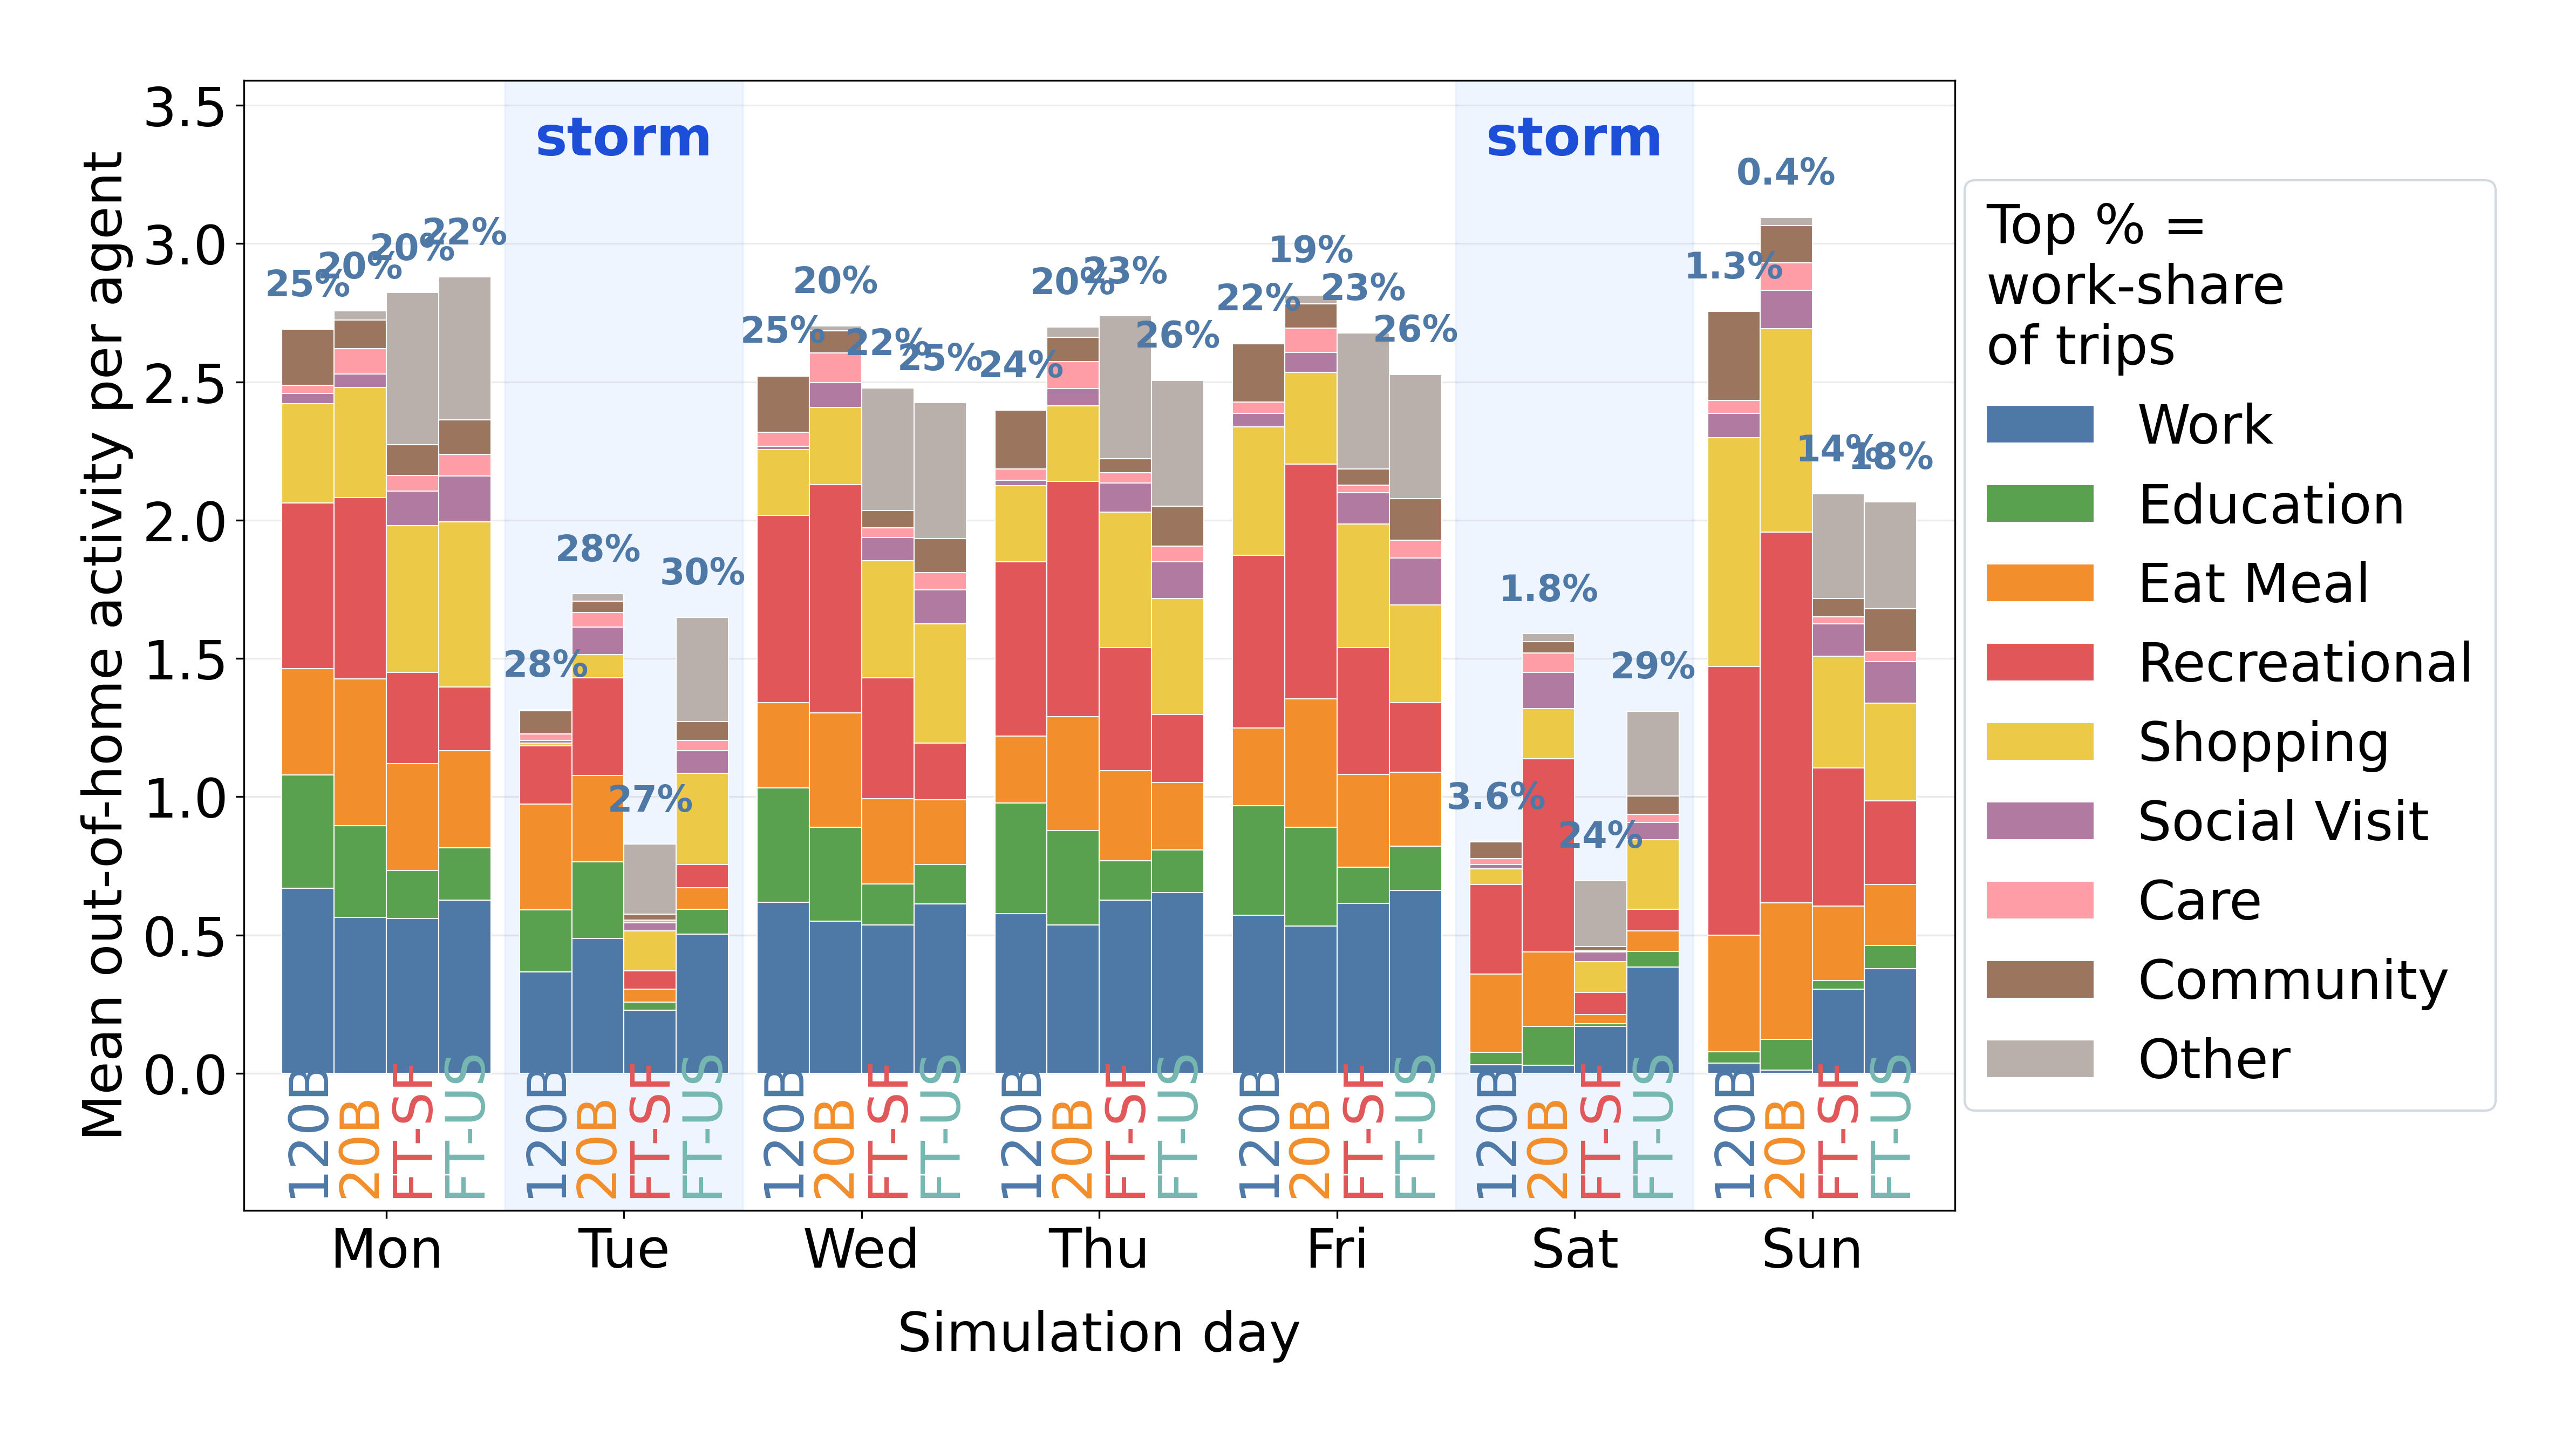

In [5]:
fig_weekly_activity_mix, ax_weekly_activity_mix, scenario_weekly_activity_mix = make_weekly_activity_mix_figure(
    scenario_frames,
    model_order=MODEL_ORDER,
    day_order=DAY_ORDER,
    day_short_labels=DAY_SHORT_LABELS,
    storm_day_names=STORM_DAY_NAMES,
    activity_codes=ACTIVITY_CODES,
    activity_labels=ACTIVITY_LABELS,
    activity_colors=ACTIVITY_COLORS,
    model_colors=MODEL_COLORS,
    model_short=MODEL_SHORT,
    font_size=DEFAULT_FONT_SIZE,
    font_size_s=DEFAULT_FONT_SIZE_S,
    font_size_ws=DEFAULT_FONT_SIZE_WS,
    legend_ncol=WEEKLY_LEGEND_NCOL,
    legend_loc=WEEKLY_LEGEND_LOC,
    legend_bbox_to_anchor=WEEKLY_LEGEND_BBOX,
    figsize=DEFAULT_FIGSIZE,
)

# fig_weekly_activity_mix.savefig(
#     "/Users/prb977/Project/MMv4/_COLM_2026__Large_Scale_Urban_Simulation_with_LLMs/figures/storm_weekly_activity_mix.png",
#     dpi=300,
#     bbox_inches="tight",
# )



In [6]:
show_agent_story_compare(
    agent_id=8429,
    models=["OSS_120B"],
    days=[2 ],
)

Time,Activity,Rationale,Stay (min),Decision reasoning
05:55,Home (1),"It's early morning and a severe storm is forecast, so I stay at home to prepare breakfast and get the children ready while delaying the school drop‑off until conditions improve.",90,"Decision reasoningWe need to decide next activity given current context: Time Tuesday 05:55, at Home, and today plan. The storm forecast, should limit travel, so likely stay at home longer, perhaps prepare breakfast and get kids ready, maybe take kids to school later? But if severe storm, maybe kids will have remote learning or delayed school. As a lecturer, may also work from home.We need to output JSON with rationale, next_activity_type (code), stay_minutes.Current activity is Home and we are at Home now. How long to stay? The plan says start day at home preparing breakfast and driving kids to school before storm hits. But storm forecast severe, so maybe decide to stay home and avoid travel, maybe have kids remote school. So we could stay home, continue preparing breakfast and maybe start work remote. So we could stay home for, say, 2 hours (120 minutes) covering breakfast, kids ready, maybe wait for situation. Or maybe stay until 7:30 to do breakfast and get kids ready. Current time 05:55. Typically breakfast around 6:30-7:00. Let's say stay at Home for 90 minutes (until ~07:25). That seems plausible.Thus next_activity_type = 1 (Home). stay_minutes = 90. Rationale: ""It's early morning and a severe storm is forecast, so I stay at home to prepare breakfast and get the children ready while delaying the school drop‑off until conditions improve.""Return JSON."
07:30,Home (1),Stay at home a bit longer to finish breakfast and get the kids ready while waiting for the storm to pass before attempting any travel.,45,"Decision reasoningWe need to decide next action at current time 07:30, location Home. Rough plan: prepare breakfast and drive kids to school before storm hits, then work remotely, etc. However there is severe storm forecast, travel disruption. At 07:30, we have been at Home for 640 minutes according to memory (makes no sense; it's a memory from earlier maybe). But the current context says we are at Home 07:30. Need decide next activity.We have to consider that the storm now maybe starting, so maybe we should stay home longer, work remotely, skip driving kids now, maybe delay school drop-off. The plan originally: prepare breakfast, drive kids to school before storm hits. However storm forecast severe, advised limit travel. So maybe we keep kids at home, set up remote schooling? But as a lecturer, she may also have remote teaching.Thus next activity likely remains Home, staying for some minutes, maybe making breakfast, getting kids ready, etc. How long? Breakfast & prep maybe 30-45 minutes. At 07:30, could stay 45 minutes until 08:15, then maybe decide about school drop. Since travel is discouraged, maybe still do a short drive if it's safe later, but we decide to stay home to wait, maybe start remote work later.Thus next activity type = 1 (Home). stay_minutes maybe 45. Rationale: Continue preparing breakfast and getting kids ready while waiting for storm to subside before attempting travel.Return JSON."
08:20,Home (1),Continue preparing breakfast and getting the kids ready while waiting for the storm to improve before the school drop‑off.,30,"Decision reasoningWe have to decide next activity at time 08:20 Tuesday, location Home. The plan: breakfast, drive kids to school before morning storm, then work remotely from home office most of day. But the storm is severe, advised to limit travel. At 08:20, they have been at home for 690 minutes? That seems off: 690 minutes from midnight is 11.5h, i.e., 11:30. But they are at home at 08:20. The memory entry ""At 08:20 on 2025-09-09 you were at Home for 690 minutes."" maybe unrealistic. However, we need to decide next activity. Since they are at home currently, likely continue Home activity preparing breakfast, maybe stay for some mi

'\n<style>\n.agent-story-root {\n  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;\n  color: #0f172a;\n}\n.agent-story-title {\n  margin: 0 0 14px 0;\n  font-size: 26px;\n  font-weight: 700;\n}\n.agent-story-subtitle {\n  margin: 0 0 20px 0;\n  color: #475569;\n  font-size: 14px;\n}\n.agent-story-profile-card {\n  border: 1px solid #dbe2ea;\n  border-radius: 14px;\n  background: #f8fafc;\n  padding: 14px 16px;\n  margin: 0 0 18px 0;\n}\n.agent-story-profile-headline {\n  margin: 0 0 10px 0;\n  font-size: 18px;\n  font-weight: 700;\n}\n.agent-story-profile-grid {\n  display: grid;\n  grid-template-columns: repeat(auto-fit, minmax(240px, 1fr));\n  gap: 8px 14px;\n}\n.agent-story-profile-item {\n  font-size: 13px;\n  line-height: 1.45;\n}\n.agent-story-profile-item strong {\n  color: #334155;\n}\n.agent-story-model-card {\n  border: 1px solid #dbe2ea;\n  border-radius: 16px;\n  background: #ffffff;\n  padding: 18px 18px 8px 18px;\n  margin: 0 0 18px 0;\n  box-shado

In [7]:
show_agent_story_compare(
    agent_id=67985,
    models=["OSS-20B-FT-SF"],
    days=[6],
)

Time,Activity,Rationale,Stay (min),Decision reasoning
00:05,Home (1),"I'm still asleep, but I need to wake up soon to get bundled up and fully ready for the intense storm coming in tonight. I'll wake up, put on some thick winter gear, and gather everyone in the house so we can start prepping for a bunker-down day.",32,"Decision reasoningI'm deep in bed and it's just past midnight. With the severe storm on the horizon, I need to be bundled up and head out soon. I'll sleep for the next half hour or so, then quickly get dressed and warm before we gather everyone in the house for a bunker-down day."
00:40,Home (1),"The severe storm is fast approaching. I have an older relative staying with me downstairs, and we need to lock everything down and bunker down here. I don't want a bad headache or risking a fall-late with coming in from the streets, so we will stay put until the morning.",390,Decision reasoningIt's 00:40 on Saturday. The severe storm is rolling in tonight. Ward's office told us to limit movements. I'm already at home with my downstairs relative. We need to stay put for the next 6.5 hours (390 minutes) until dawn so I can figure out the bunker-down plan. I'll stay home (1) for 390 minutes.
07:15,Home (1),"It's morning, but with the storm approaching, I'm staying bunkered down with my relative. I will use this time to slowly grind through a few remaining chores, make some warm meals, and just take it easy indoors for the bulk of the day.",420,"Decision reasoningMorning has come, and it is indeed 7:15 AM. The storm is still coming, so I'm decided on staying this whole day bunkered down. I'll extend my stay at home for a solid block of around seven hours (420 minutes). That will cover afternoon chores, meals, and some much needed downtime. I'll just rest until the storm passes."
14:20,Home (1),"With the severe storm and city-wide travel advisories in effect, I'm going to stay bunkered down with my older relative for the rest of the afternoon, evening, and night. I'm going to stay here to make more warm food, check on them occasionally, and just focus on staying dry and safe indoors as the weather rages outside.",1000,"Decision reasoningIt's 2:20 PM on Saturday, and the forecast is pretty clear on what I need to do. With the severe storm we're facing and heavy disruptions expected across the city, there's absolutely no point in exposing myself to the weather or pushing my older relative out there. They're already pretty tired from being indoors all morning, and I want to make sure we have blankets and pre-made snacks handy in case power gets knocked out later. I'll just continue staying put, maybe make another warm batch of soup, and start catching up on some movies or a new TV series to watch together. I'll plan to stay here and bunker down for the rest of the day and night, checking on the storm updates occasionally from the living room."


'\n<style>\n.agent-story-root {\n  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;\n  color: #0f172a;\n}\n.agent-story-title {\n  margin: 0 0 14px 0;\n  font-size: 26px;\n  font-weight: 700;\n}\n.agent-story-subtitle {\n  margin: 0 0 20px 0;\n  color: #475569;\n  font-size: 14px;\n}\n.agent-story-profile-card {\n  border: 1px solid #dbe2ea;\n  border-radius: 14px;\n  background: #f8fafc;\n  padding: 14px 16px;\n  margin: 0 0 18px 0;\n}\n.agent-story-profile-headline {\n  margin: 0 0 10px 0;\n  font-size: 18px;\n  font-weight: 700;\n}\n.agent-story-profile-grid {\n  display: grid;\n  grid-template-columns: repeat(auto-fit, minmax(240px, 1fr));\n  gap: 8px 14px;\n}\n.agent-story-profile-item {\n  font-size: 13px;\n  line-height: 1.45;\n}\n.agent-story-profile-item strong {\n  color: #334155;\n}\n.agent-story-model-card {\n  border: 1px solid #dbe2ea;\n  border-radius: 16px;\n  background: #ffffff;\n  padding: 18px 18px 8px 18px;\n  margin: 0 0 18px 0;\n  box-shado

## Persona Consistency and Memory

In [8]:
SIM_RUNS = {
    "OSS_20B": "simulation_outputs/SF_1k_oss_20b",
    "OSS_120B": "simulation_outputs/SF_1k_oss_120b",
    "OSS-20B-FT-SF": "simulation_outputs/SF_1k_oss_20b_lora-sf-5epoch",
    "OSS-20B-FT-US": "simulation_outputs/SF_1k_oss_20b_lora-5epoch",
}

SIM_RUN_INPUT_FOLDERS = {
    "OSS_20B": "Inputs/SF_agents_1K",
    "OSS_120B": "Inputs/SF_agents_1K",
    "OSS-20B-FT-SF": "Inputs/SF_agents_1K",
    "OSS-20B-FT-US": "Inputs/SF_agents_1K",
}

SEED = 42
TARGET_TAXONOMY = "new10"
DAY_ORDER = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]
DAY_SHORT_LABELS = {
    "Monday": "Mon",
    "Tuesday": "Tue",
    "Wednesday": "Wed",
    "Thursday": "Thu",
    "Friday": "Fri",
    "Saturday": "Sat",
    "Sunday": "Sun",
}
# STORM_DAY_NAMES = {"Tuesday", "Saturday"}

MODEL_ORDER = [
    "OSS_120B",
    "OSS_20B",
    "OSS-20B-FT-SF",
    "OSS-20B-FT-US",
]
MODEL_DISPLAY = {
    "OSS_120B": "OSS-120B",
    "OSS_20B": "OSS-20B",
    "OSS-20B-FT-SF": "OSS-20B-FT-SF",
    "OSS-20B-FT-US": "OSS-20B-FT-US",
}
MODEL_SHORT = {
    "OSS_120B": "120B",
    "OSS_20B": "20B",
    "OSS-20B-FT-SF": "FT-SF",
    "OSS-20B-FT-US": "FT-US",
}
MODEL_COLORS = {
    "OSS_120B": "#4e79a7",
    "OSS_20B": "#f28e2b",
    "OSS-20B-FT-SF": "#e15759",
    "OSS-20B-FT-US": "#76b7b2",
}

ACTIVITY_CODES = [2, 4, 3, 5, 6, 10, 7, 8, 9]
ACTIVITY_LABELS = {code: NEW_LOC_TYPES[code] for code in ACTIVITY_CODES}
ACTIVITY_COLORS = {
    2: "#4e79a7",
    4: "#59a14f",
    3: "#f28e2b",
    5: "#e15759",
    6: "#edc948",
    10: "#b07aa1",
    7: "#ff9da7",
    8: "#9c755f",
    9: "#bab0ab",
}

DEFAULT_FIGSIZE = (15, 8)
DEFAULT_FONT_SIZE = 24
DEFAULT_FONT_SIZE_S = 24

LINE_LEGEND_NCOL = 4
LINE_LEGEND_LOC = "upper center"
LINE_LEGEND_BBOX = (0.5, 1.18)

WEEKLY_LEGEND_NCOL = 1
WEEKLY_LEGEND_LOC = "center left"
WEEKLY_LEGEND_BBOX = (0.99, 0.5)

scenario_frames = load_simulation_run_dict(
    SIM_RUNS,
    day_selector="all",
    seed=SEED,
    run_input_folders=SIM_RUN_INPUT_FOLDERS,
    target_taxonomy=TARGET_TAXONOMY,
)

for name in MODEL_ORDER:
    df = scenario_frames[name]
    print(name, len(df), "rows", df["agent_id"].nunique(), "agents")



[cohort-join] OSS_20B: joined from Inputs/SF_agents_1K
Normalizing simulation dataframe with columns: ['agent_id', 'agent_type', 'combined_time', 'date', 'graph', 'loc_type', 'loc_type2', 'loc_type_new', 'location', 'person_class', 'travel_time', 'travel_times']
[cohort-join] OSS_120B: joined from Inputs/SF_agents_1K
Normalizing simulation dataframe with columns: ['agent_id', 'agent_type', 'combined_time', 'date', 'graph', 'loc_type', 'loc_type2', 'loc_type_new', 'location', 'person_class', 'travel_time', 'travel_times']
[cohort-join] OSS-20B-FT-SF: joined from Inputs/SF_agents_1K
Normalizing simulation dataframe with columns: ['agent_id', 'agent_type', 'combined_time', 'date', 'graph', 'loc_type', 'loc_type2', 'loc_type_new', 'location', 'person_class', 'travel_time', 'travel_times']
[cohort-join] OSS-20B-FT-US: joined from Inputs/SF_agents_1K
Normalizing simulation dataframe with columns: ['agent_id', 'agent_type', 'combined_time', 'date', 'graph', 'loc_type', 'loc_type2', 'loc_type_

In [9]:
show_agent_story_compare(
    agent_id=82286,
    models=["OSS_120B"],
    days=[1, 3,6],
)

Time,Activity,Rationale,Stay (min),Decision reasoning
07:05,Home (1),"Finish getting my toddler dressed, have a quick breakfast, and prepare everything we need before leaving for daycare and then heading to my shift.",20,"Decision reasoningWe have current time Monday 2025-09-08 07:05, location Home. The rough plan: morning at home getting toddler ready for daycare before heading to work shift at shop-kitchen 8am-5pm. At 07:05 we are home. Need to decide next activity. Likely continue Home activity for some minutes (preparing toddler, etc.) with a duration until maybe 7:45 or 7:55 to then travel to daycare (Education) and then to work.We need to consider travel time. In San Francisco, commuting from home to daycare (maybe nearby) maybe 15 minutes, then to work maybe another 20 minutes. But schedule says shift starts 8am; we need to leave home to get toddler to daycare (maybe at 7:30). So stay at home for ~20 minutes (until 7:25). So we can set stay_minutes = 20 (or 25). The next activity could be Education (drop off toddler). The activity code for Education is 4. Provide rationale: ""Finish getting toddler dressed, have breakfast, and drop them off at daycare before heading to work.""Thus decision: continue Home for 20 min? Actually we are already at Home; we could extend stay at Home for next 20 minutes, then later decision will be daycare. But the question: ""Return JSON ONLY"" - we need to provide next activity type and stay_minutes. At this decision point, we are at Home, we could choose to stay at Home for X minutes. That's consistent. So next_activity_type = 1 (Home). stay_minutes = 20 (or 25). Rationale: ""Finish morning routine with toddler before leaving for daycare and work.""Let's choose 20 minutes to bring time to 07:25.Return JSON."
07:30,Home (1),"Finish getting my toddler dressed, have a quick breakfast, and gather everything we need before leaving for daycare and my shift.",20,"Decision reasoningWe need to decide next activity at 07:30 Monday. Current location Home. Rough plan: finish getting toddler ready, then go to daycare then work. At 07:30 they've been at Home for 450 minutes? That seems contradictory: earlier memory says at 07:30 they were at Home for 450 minutes (i.e., 7.5h). But the timeline: day started at midnight? Actually 00:00-now Home. That's weird. But we need to pick next activity.At 07:30 they are at Home. They should continue Home to finish toddler prep and possibly travel to daycare. Likely stay at Home for maybe 15 minutes more (till 07:45) then leave. Duration realistic: 15-20 minutes to finish dressing, breakfast, pack bag. So choose activity code 1 (Home) with stay_minutes maybe 20.Rationale: finishing morning routine with toddler before heading to daycare and work.Thus JSON."
07:55,Home (1),"Finishing getting my toddler dressed, having a quick breakfast, and gathering everything we need before leaving for daycare and my work shift.",10,"Decision reasoningWe are at Monday 2025-09-08 07:55, location Home. The plan: get toddler ready for daycare, then go to work shift starting around 8 am. Currently at 07:55, likely still at home. Need to decide next activity. At 07:55, still could be finishing getting toddler ready. The plan says stay at home for about 20 minutes earlier. At 07:55, maybe still at home, but soon will need to leave for daycare and work. So we could decide to continue Home activity for maybe 10 minutes (till 08:05) to finish prep, then head out. But the simulation will handle travel in separate steps. So now decision: stay at Home for maybe 10 minutes. Provide rationale: finish dressing toddler, quick breakfast, gather things before leaving for daycare and work.Let's output JSON with rationale, next_activity_type = 1 (Home), stay_minutes = 10.Check duration: realistic. Probably 5-10 minutes remaining. So choose 10.Return JSON only."
08:10,Education (4),Drop my toddler off at daycare before heading to my shift at the shop‑kitchen.,30,"Decision reasoningWe have context: Time Mo

'\n<style>\n.agent-story-root {\n  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif;\n  color: #0f172a;\n}\n.agent-story-title {\n  margin: 0 0 14px 0;\n  font-size: 26px;\n  font-weight: 700;\n}\n.agent-story-subtitle {\n  margin: 0 0 20px 0;\n  color: #475569;\n  font-size: 14px;\n}\n.agent-story-profile-card {\n  border: 1px solid #dbe2ea;\n  border-radius: 14px;\n  background: #f8fafc;\n  padding: 14px 16px;\n  margin: 0 0 18px 0;\n}\n.agent-story-profile-headline {\n  margin: 0 0 10px 0;\n  font-size: 18px;\n  font-weight: 700;\n}\n.agent-story-profile-grid {\n  display: grid;\n  grid-template-columns: repeat(auto-fit, minmax(240px, 1fr));\n  gap: 8px 14px;\n}\n.agent-story-profile-item {\n  font-size: 13px;\n  line-height: 1.45;\n}\n.agent-story-profile-item strong {\n  color: #334155;\n}\n.agent-story-model-card {\n  border: 1px solid #dbe2ea;\n  border-radius: 16px;\n  background: #ffffff;\n  padding: 18px 18px 8px 18px;\n  margin: 0 0 18px 0;\n  box-shado